# 单切片 DLPFC

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff_improved").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff_improved as sd
from SpaDiff_improved.spatial import spatial_reconstruction
from SpaDiff_improved.utils import mclust_R, set_seed


## 参数

In [2]:
SEED = 42
SAMPLE_ID = "151672"
N_CLUSTERS = 5
N_NEIGHBORS = 10

K1 = 1.0
K2 = 0.0
REPRODUCE_ORIGINAL = K1 > 0.0 and K2 == 0.0

# CLUSTER_METHOD = "mclust"

DATA_ROOT = Path("E:/gxy_2/final/0_data/case1")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device =torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)
print(f"loss = {K1} * original_DEC + {K2} * diffusion_DSM")


DATA_ROOT = E:\gxy_2\final\0_data\case1
device = cuda:0
loss = 1.0 * original_DEC + 0.0 * diffusion_DSM


## 读取数据

In [3]:
sample_dir = DATA_ROOT / SAMPLE_ID
adata = sc.read_visium(sample_dir)
adata.var_names_make_unique()


adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts", n_top_genes=3000, subset=True)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# sc.pp.scale(adata, max_value=10)

truth = pd.read_csv(sample_dir / "truth.txt", sep="\t", header=None, index_col=0)
truth.columns = ["Truth"]
adata.obs["Truth"] = truth.reindex(adata.obs_names)["Truth"]
adata


AnnData object with n_obs × n_vars = 4015 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'counts'

## 构建单纯复形

In [4]:

adata, operators = spatial_reconstruction(adata,alpha = 5.0,n_neighbors=N_NEIGHBORS,device=device)


sc.tl.pca(adata, n_comps=50)

features = torch.as_tensor(np.asarray(adata.obsm["X_pca"]), dtype=torch.float32, device=device)

batch_ids = torch.zeros(adata.n_obs, dtype=torch.long, device=device)
modality_ids = torch.zeros(adata.n_obs, dtype=torch.long, device=device)

print("features:", tuple(features.shape))
print("edge nnz:", operators[1]._nnz(), "triangle nnz:", operators[2]._nnz())


features: (4015, 50)
edge nnz: 42101 triangle nnz: 42101


## 训练条件 VP-SDE

In [5]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    num_batches=1,
    num_modalities=1,
    num_scales=1000,
    topology_hidden_dim=64,
    topology_dim=128,
    propagation_steps= 10,
    propagation_alpha= 0.5,
    hidden_dim=128,
    dropout=0.2,
    topology_projection_dropout=0.1,
    k1=K1,
    k2=K2,
    num_clusters=N_CLUSTERS,
    dec_alpha=1.0,
    dec_update_interval=10,
    dec_tolerance=1e-4,
    dec_init_method="mclust",
    random_seed=SEED,
)
model = sd.SpaDiff(config).to(device)
training_epochs = 100
training = sd.train_spadiff(
    model,
    features,
    operators,
    batch_ids,
    modality_ids,
    epochs=training_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    ema_decay=None if REPRODUCE_ORIGINAL else 0.999,
    verbose_every=1 if REPRODUCE_ORIGINAL else 25,
)
print("best total loss =", training.best_loss)
print("last original DEC loss =", training.original_losses[-1])
print("last diffusion loss =", training.diffusion_losses[-1])


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 5.4.10
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Epoch 0001/100 | total=0.143903 | original=0.143903 | diffusion=0.000000
Epoch 0002/100 | total=0.136359 | original=0.136359 | diffusion=0.000000
Epoch 0003/100 | total=0.123650 | original=0.123650 | diffusion=0.000000
Epoch 0004/100 | total=0.113158 | original=0.113158 | diffusion=0.000000
Epoch 0005/100 | total=0.105139 | original=0.105139 | diffusion=0.000000
Epoch 0006/100 | total=0.100856 | original=0.100856 | diffusion=0.000000
Epoch 0007/100 | total=0.093798 | original=0.093798 | diffusion=0.000000
Epoch 0008/100 | total=0.086141 | original=0.086141 | diffusion=0.000000
Epoch 0009/100 | total=0.078759 | original=0.078759 | diffusion=0.000000
Epoch 0010/100 | total=0.077327 | original=0.077327 | diffusion=0.000000
Epoch 0011/100 | total=0.185922 | original=0.185922 | diffusion=0.000000
Epoch 0012/100 | total=0.171726 | original=0.171726 | diffusion=0.000000
Epoch 0013/100 | total=0.162566 

## 使用 EMA 权重进行拓扑条件去噪

In [6]:
if REPRODUCE_ORIGINAL:
    dec_labels, dec_prob, embedding = model.original_predict(features, operators)
    denoised = embedding
else:
    if training.ema is not None:
        training.ema.store(model.parameters())
        training.ema.copy_to(model.parameters())
    try:
        denoised = model.harmonize(
            observed_features=features,
            operators=operators,
            reference_batch_ids=batch_ids,
            modality_ids=modality_ids,
            strength=0.20,
            sampler="ode",
            guidance_scale=1.0,
            ode_steps=200,
        )
    finally:
        if training.ema is not None:
            training.ema.restore(model.parameters())

adata.obsm["spadiff"] = denoised.cpu().numpy()


## 空间域识别与 ARI

In [7]:
# adata.obs["pre"] = pd.Categorical(dec_labels.detach().cpu().numpy().astype(str))
# valid = adata.obs[["pre", "Truth"]].dropna()
# ari = round(adjusted_rand_score(valid["Truth"], valid["pre"]),3)
# print(f"ARI = {ari:.3f}")
# sc.pl.spatial(
#     adata, img_key="hires", color="pre", 
#     title=f"ARI={ari:.3f}", legend_loc=None,
#     frameon=False, spot_size=120,)

In [8]:

labels = mclust_R(adata, num_cluster=N_CLUSTERS, used_obsm="spadiff", pca_num=20)
adata.obs["mclust"] = pd.Categorical(labels.astype(str))
valid = adata.obs[["mclust", "Truth"]].dropna()
ari = round(adjusted_rand_score(valid["Truth"], valid["mclust"]),3)
nmi = normalized_mutual_info_score(valid["Truth"], valid["mclust"])

print(f"ARI = {ari:.3f}")
print(f"NMI = {nmi:.3f}")


fitting ...
  |======================================================================| 100%
ARI = 0.561
NMI = 0.677


[<AxesSubplot: title={'center': 'SpaDiff original DEC reproduction | ARI=0.561'}, xlabel='spatial1', ylabel='spatial2'>]

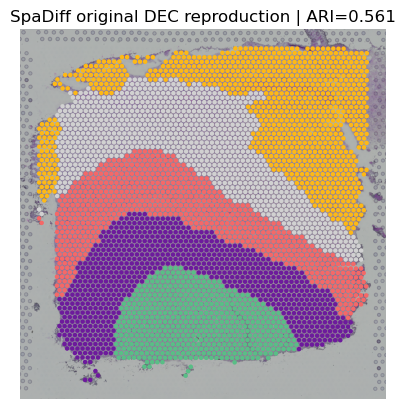

In [9]:
import matplotlib.pyplot as plt
palette = ["#6D1A9C", "#D1D1D1", "#F56867", "#59BE86", "#FEB915", "#C798EE", "#7495D3"]
mode = "original DEC reproduction" if REPRODUCE_ORIGINAL else f"hybrid k1={K1:g}, k2={K2:g}"
sc.pl.spatial(
    adata, img_key="hires", color="mclust", palette=palette,
    title=f"SpaDiff {mode} | ARI={ari:.3f}", legend_loc=None,
    frameon=False, spot_size=120,
    show=False
)
# plt.savefig("../result/spadiff_"+SAMPLE_ID+"_"+str(ari)+".pdf", bbox_inches='tight')

In [10]:
# for i in range(15,33):
#     print(f"pca:{i}")
#     labels = mclust_R(adata, num_cluster=N_CLUSTERS, used_obsm="spadiff", pca_num=i)
#     adata.obs["mclust"] = pd.Categorical(labels.astype(str))
#     valid = adata.obs[["mclust", "Truth"]].dropna()
#     ari = round(adjusted_rand_score(valid["Truth"], valid["mclust"]),3)
#     print(f"ARI = {ari:.3f}")
    
#     if ari >= 0.77:
#         break


In [11]:
# output_file ="../result/spadiff_"+SAMPLE_ID+"_"+str(ari)+".h5ad"  # 压缩后的 h5ad 文件路径

# adata.write_h5ad(output_file, compression="gzip")